# Lab Segmentation 1

In [7]:
from commonfunctions import *
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.morphology import binary_erosion, binary_dilation, binary_closing,skeletonize, thin
from skimage.measure import find_contours
from skimage.draw import rectangle

# Show the figures / plots inside the notebook
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


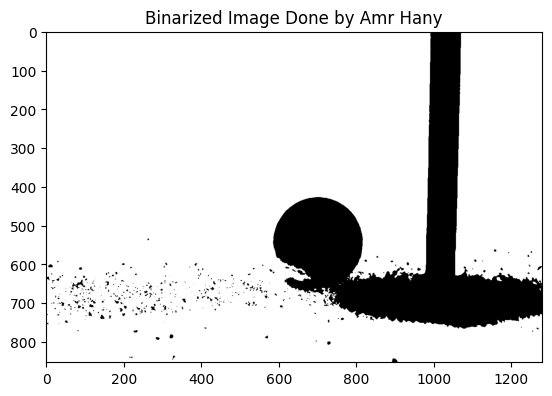

In [37]:
## For all requirements: The quality of the results is evaluated.


# 1- Read the image 
# [VERY IMPORTANT] and convert it to float: image = image.astype(float)
# read image golf
image = io.imread('./imgs/exp1/golf.jpeg')

image = image.astype(float)





# 2- Retreive the 3 channels of the image(R,G,B) (will be used in the coming steps)

R = image[:,:,0]
G = image[:,:,1]
B = image[:,:,2]


# 3- Visually (not by code) detect the dominating color channel (C) for the backgroung (R, G or B)
# rgb(78, 90, 76) from the online website so the dominating channel is G


# 4- Draw the dominating channel (r, g or b) thresholded by some threshold (to make sure your choice is meaningful)
threshold = 100
dominant_channel = G
thresholded_image = (dominant_channel > threshold).astype(float)


# 5- Get an intuitive way(There is a very simple way) to make a mask that can get the pixels where the values of the dominating channels 
# have larger values than the other channels with an appropriate threshold 
mask = (dominant_channel - np.maximum(R, B)) > 15
binarized_image = mask.astype(float)


# 6- display the binarized image
show_images([binarized_image], ["Binarized Image Done by Amr Hany"])






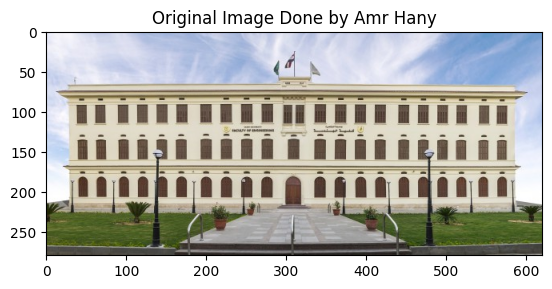

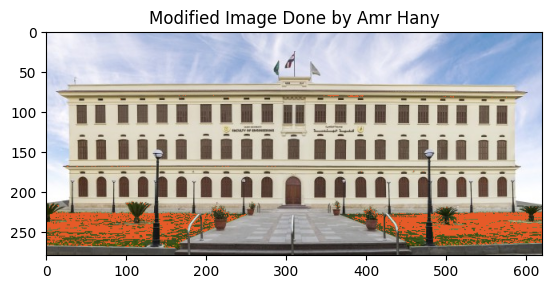

In [38]:
# 1- Get the required RGB color (Using a color picker)
# required color is R = 83 , G = 105 , B=50

# 2- Read image
image = io.imread('./imgs/exp2/cufe.png')

show_images([image], ["Original Image Done by Amr Hany"])

image = image.astype(float)


# 3- extract R, G and B channels (as float)
R = image[:,:,0]
G = image[:,:,1]
B = image[:,:,2]

# 4- calculate differences FOR EACH CHANNEL (between the image and the required pixel value)
required_color = np.array([83, 105, 50]).astype(float)
diff_R = np.abs(R - required_color[0])
diff_G = np.abs(G - required_color[1])
diff_B = np.abs(B - required_color[2])

# 5- calculate overall distance from the given RGB color (use any appropriate distance measure, take care of the minus distances)
overall_distance = np.sqrt(diff_R**2 + diff_G**2 + diff_B**2)

# 6-  create a mask by thresholding the differences
distance_threshold =25
mask = overall_distance < distance_threshold

# 7- In the input image, Replace the pixels of the mask with the following color
# R = 230 , G = 90 , B=40
image[mask] = [230, 90, 40]

# 8- show the image or save it
show_images([image.astype(np.uint8)], ["Modified Image Done by Amr Hany"])
